# Data analysis project of the Marfan Power study as part of the teaching unit Movement Analysis
by Chloé Laignel-Granier

##  Introduction

This notebook presents the data preprocessing and visualization pipeline for the analysis of patients with Marfan syndrome.

The primary objective was to evaluate changes in functional capacity following intervention, using the 6-minute walk test (6MWT) as the main outcome.

Data were first cleaned and standardized to ensure consistency. Patients were then selected based on the availability of complete pre- and post-intervention data, and a dataset suitable for analysis was constructed.

Descriptive analyses and visualizations were performed in Python to explore the data and illustrate individual and group-level changes. The cleaned datasets were subsequently exported to R for statistical analyses.

This pipeline ensures a reproducible and transparent workflow from raw data to statistical analysis.

## Export HTML

<script>
$(document).ready(function(){

  // Hide all code blocks at start
  $('div.sourceCode').hide();

  // Add toggle button before each code block
  $('div.sourceCode').each(function(){
    var button = $('<button class="toggle-code">Show code</button>');
    $(this).before(button);

    button.click(function(){
      $(this).next('div.sourceCode').toggle();
      
      if ($(this).text() === "Show code") {
        $(this).text("Hide code");
      } else {
        $(this).text("Show code");
      }
    });
  });

});
</script>

## Step 1 : Upload the Excel data to Python

In [13]:
# Load dataset
import pandas as pd
import numpy as np
file_path = "data/Marfan.xlsx"
data = pd.read_excel(file_path)

# Display first rows and info about the dataset
print(data.head())
print(data.info())

# Total number of patients
len(data)


   ID        age sexe  weight_kg  height_cm  BMI_kg_cm2  \
0   1  10.529774    M       47.8      162.6   18.079517   
1   2  14.351814    F       43.0      174.0   14.202669   
2   3  10.704997    M       26.0      142.0   12.894267   
3   4  17.393566    F       69.0      185.5   20.052165   
4   5  18.986995    F       54.8      177.0   17.491781   

   6minWT_Distance_traveled_m_before  6minWT_Distance_traveled_m_after  \
0                                660                             737.0   
1                                598                               NaN   
2                                556                             618.0   
3                                588                             692.0   
4                                583                               NaN   

   VO2_SV1__percent_theoretical_before  VO2_SV1__percent_theoretical_after  \
0                            29.918262                           39.958707   
1                            38.742243      

28

The dataset was imported from an Excel file containing clinical and functional data of patients with Marfan syndrome.

There are 28 patients.

## Step 2 : Clean data

In [14]:
# Rename columns for clarity
data = data.rename(columns={
    "VO2_SV1__percent_theoretical_after": "VAT_after",
    "VO2_SV1__percent_theoretical_before": "VAT_before"
})

The columns have been renamed " VO2_SV1__percent_theoretical" to VAT

In [15]:
# Standardize variable names
data.columns = data.columns.str.lower().str.strip()
data.head()

,id,age,sexe,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,pedsql_totalself_before,pedsql_totalself_after
0,1,10.529774,M,47.8,162.6,18.079517,660,737.0,29.918262,39.958707,69.565217,75.000000
1,2,14.351814,F,43.0,174.0,14.202669,598,NaN,38.742243,NaN,86.956522,NaN
2,3,10.704997,M,26.0,142.0,12.894267,556,618.0,38.237739,41.531482,92.391304,92.391304
3,4,17.393566,F,69.0,185.5,20.052165,588,692.0,28.950695,45.052754,52.173913,57.608696
4,5,18.986995,F,54.8,177.0,17.491781,583,NaN,39.959155,NaN,76.086957,70.652174


Variable names were standardized by converting all column names to lowercase and removing leading and trailing spaces to ensure consistency and prevent errors during data processing.

In [16]:
# Data quality checks

# Check that the pandas recognize the NaN
print(data.isna().sum())

# Check for duplicates
data.duplicated(). sum()

# Check for outliers
data.describe()

id                                   0
age                                  0
sexe                                 0
weight_kg                            0
height_cm                            0
bmi_kg_cm2                           0
6minwt_distance_traveled_m_before    0
6minwt_distance_traveled_m_after     8
vat_before                           0
vat_after                            8
pedsql_totalself_before              0
pedsql_totalself_after               6
dtype: int64


,id,age,weight_kg,height_cm,bmi_kg_cm2,6minwt_distance_traveled_m_before,6minwt_distance_traveled_m_after,vat_before,vat_after,pedsql_totalself_before,pedsql_totalself_after
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,20.000000,28.000000,20.000000,28.000000,22.000000
mean,14.500000,12.823409,46.917857,166.075000,16.443043,583.107143,619.250000,34.631787,42.838515,71.739130,78.903162
std,8.225975,3.690520,16.818289,19.542596,3.415743,48.962071,79.940027,8.546636,9.699341,15.078733,11.158979
min,1.000000,7.186858,22.000000,134.000000,12.071331,450.000000,460.000000,18.356884,25.183949,34.782609,57.608696
25%,7.750000,10.254620,31.250000,149.250000,13.607551,559.000000,582.500000,29.009876,38.749706,64.673913,72.010870
50%,14.500000,12.513347,48.400000,167.500000,15.015128,588.000000,610.000000,33.780836,42.061119,69.565217,77.717391
75%,21.250000,15.500342,59.375000,182.250000,18.940916,621.250000,684.500000,38.947333,47.765170,83.967391,87.771739
max,28.000000,19.879535,82.000000,199.000000,24.485652,660.000000,744.000000,56.480397,63.142768,93.478261,97.826087


Data quality was assessed by examining missing values, duplicate observations, and descriptive statistics. 

Missing data were quantified for each variable, duplicate entries were checked, and summary statistics were used to identify potential outliers and inconsistencies.

## Step 3—Separate the analyzed and excluded patients

In [17]:
# Define key variables for analysis
cols_all = [
    "6minwt_distance_traveled_m_before",
    "6minwt_distance_traveled_m_after",
    "vat_before",
    "vat_after",
    "pedsql_totalself_before",
    "pedsql_totalself_after"
]

# Analysable patients (no missing data)
data_inclus = data.dropna(subset=cols_all)

# Patients were excluded if at least one missing value was present in key outcome variables (6MWT or VAT or PedsQL)
# Excluded patients
data_exclus = data[data[cols_all].isna().any(axis=1)]

# Verification
print("Total patients :", len(data))
print("Inclus :", len(data_inclus))
print("Exclus :", len(data_exclus))

# Check the excluded patients
print(data_exclus[cols_all])

Total patients : 28
Inclus : 20
Exclus : 8
    6minwt_distance_traveled_m_before  6minwt_distance_traveled_m_after  \
1                                 598                               NaN   
4                                 583                               NaN   
6                                 635                               NaN   
11                                634                               NaN   
15                                593                               NaN   
16                                568                               NaN   
24                                580                               NaN   
26                                588                               NaN   

    vat_before  vat_after  pedsql_totalself_before  pedsql_totalself_after  
1    38.742243        NaN                86.956522                     NaN  
4    39.959155        NaN                76.086957               70.652174  
6    32.164149        NaN                75.000000

Key outcome variables included the 6-minute walk test (TM6), ventilatory anaerobic threshold (VAT), and PedQsL quality of life score.

Patients with missing data in key outcome variables (6MWT or VAT) were excluded from the main analysis.

## Step 4 : Transformation to Long Format

In [18]:
# Transform the data to long format for distance traveled
distance_long = pd.melt(
    data_inclus,
    id_vars=["id"],
    value_vars=["6minwt_distance_traveled_m_before","6minwt_distance_traveled_m_after"],
    var_name="time",
    value_name="distance"
)

# Simplify the time variable
distance_long["time"] = distance_long["time"].map({
     "6minwt_distance_traveled_m_before": "T-3",
     "6minwt_distance_traveled_m_after": "T+6"
 })
print(distance_long)

    id time  distance
0    1  T-3     660.0
1    3  T-3     556.0
2    4  T-3     588.0
3    6  T-3     635.0
4    8  T-3     640.0
5    9  T-3     593.0
6   10  T-3     551.0
7   11  T-3     516.0
8   13  T-3     625.0
9   14  T-3     526.0
10  15  T-3     608.0
11  18  T-3     620.0
12  19  T-3     495.0
13  20  T-3     650.0
14  21  T-3     580.0
15  22  T-3     560.0
16  23  T-3     450.0
17  24  T-3     560.0
18  26  T-3     535.0
19  28  T-3     600.0
20   1  T+6     737.0
21   3  T+6     618.0
22   4  T+6     692.0
23   6  T+6     697.0
24   8  T+6     598.0
25   9  T+6     682.0
26  10  T+6     744.0
27  11  T+6     682.0
28  13  T+6     575.0
29  14  T+6     585.0
30  15  T+6     605.0
31  18  T+6     615.0
32  19  T+6     490.0
33  20  T+6     725.0
34  21  T+6     540.0
35  22  T+6     625.0
36  23  T+6     460.0
37  24  T+6     530.0
38  26  T+6     590.0
39  28  T+6     595.0


Data were converted to long format for visualization and paired analysis.

## Step 5 : Calculating differences

In [19]:
# Compute change (delta)
data_inclus["delta_6mwt"] = data_inclus["6minwt_distance_traveled_m_after"] - data_inclus["6minwt_distance_traveled_m_before"]
print(data_inclus[["id", "delta_6mwt"]])

    id  delta_6mwt
0    1        77.0
2    3        62.0
3    4       104.0
5    6        62.0
7    8       -42.0
8    9        89.0
9   10       193.0
10  11       166.0
12  13       -50.0
13  14        59.0
14  15        -3.0
17  18        -5.0
18  19        -5.0
19  20        75.0
20  21       -40.0
21  22        65.0
22  23        10.0
23  24       -30.0
25  26        55.0
27  28        -5.0


Individual changes in 6MWT distance were calculated as the difference between post- and pre-intervention values.

## Step 6: Data visualization

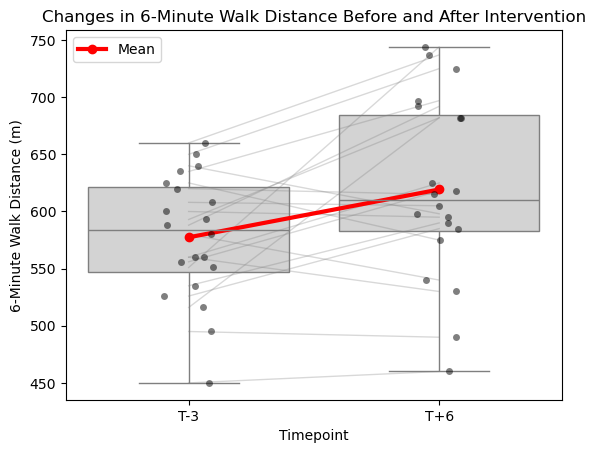

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Boxplot showing the distribution at each timepoint
sns.boxplot(
    data=distance_long,
    x="time",
    y="distance",
    color="lightgrey"
)

# Individual data points
sns.stripplot(
    data=distance_long,
    x="time",
    y="distance",
    color="black",
    alpha=0.5,
    jitter=True
)

# Paired lines for each patient (before → after)
for i in range(len(data_inclus)):
    plt.plot(
        ["T-3", "T+6"],
        [
            data_inclus["6minwt_distance_traveled_m_before"].iloc[i],
            data_inclus["6minwt_distance_traveled_m_after"].iloc[i]
        ],
        color="grey",
        alpha=0.3,
        linewidth=1
    )

# Compute mean values at each timepoint
mean_before = data_inclus["6minwt_distance_traveled_m_before"].mean()
mean_after = data_inclus["6minwt_distance_traveled_m_after"].mean()

# Add mean line (highlighted)
plt.plot(
    ["T-3", "T+6"],
    [mean_before, mean_after],
    color="red",
    linewidth=3,
    marker="o",
    label="Mean"
)

# Labels and title
plt.xlabel("Timepoint")
plt.ylabel("6-Minute Walk Distance (m)")
plt.title("Changes in 6-Minute Walk Distance Before and After Intervention")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Changes_in_6MWT_Before_After.pdf",
    bbox_inches="tight"
)

# Display the plot
plt.show()

Data were visualized using boxplots combined with individual data points and paired lines to illustrate changes between baseline (T-3) and post-intervention (T+6). 

Mean values were added to highlight overall trends in 6-minute walk distance.

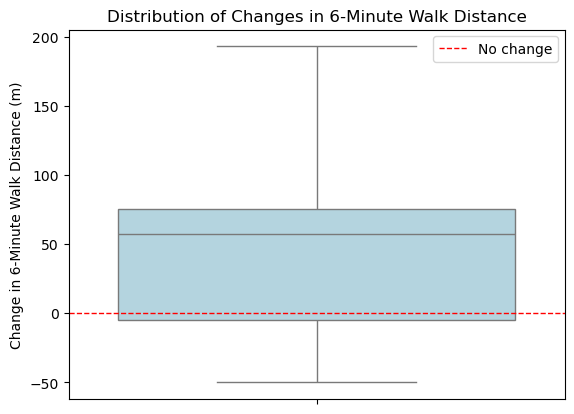

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot showing the distribution of individual changes (delta)
sns.boxplot(
    y=data_inclus["delta_6mwt"],
    color="lightblue"
)

# Add reference line at zero (no change)
plt.axhline(
    0,
    linestyle="--",
    color="red",
    linewidth=1,
    label="No change"
)

# Labels and title
plt.ylabel("Change in 6-Minute Walk Distance (m)")
plt.title("Distribution of Changes in 6-Minute Walk Distance")

# Legend
plt.legend()

# Save the figure
plt.savefig(
    "figures/Distribution_of_Changes_in_6MWT.pdf",
    bbox_inches="tight"
)

# Display the plot
plt.show()

The distribution of individual changes in 6-minute walk distance (Δ6MWT) was visualized using a boxplot. 

A horizontal reference line at zero was added to indicate no change between baseline and post-intervention measurements.

In [22]:
# Table 1. Descriptive statistics of 6-minute walk distance before and after intervention

import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. FORMAT MEDIAN [IQR] ----
summary_table = distance_long.groupby("time")["distance"].agg(
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Create formatted column
summary_table["Median [IQR]"] = (
    summary_table["Median"].round(1).astype(str) + " [" +
    summary_table["Q1"].round(1).astype(str) + "–" +
    summary_table["Q3"].round(1).astype(str) + "]"
)

# Keep only useful column
summary_table = summary_table[["Median [IQR]"]]

# Rename index
summary_table.index = ["T-3", "T+6"]


# ---- 2. DELTA SUMMARY ----
improvement = (data_inclus["delta_6mwt"] > 0).sum()
no_change = (data_inclus["delta_6mwt"] == 0).sum()
decrease = (data_inclus["delta_6mwt"] < 0).sum()

total = len(data_inclus)

delta_table = pd.DataFrame({
    "Change (n, %)": [
        f"{improvement} ({round(improvement/total*100,1)}%)",
        f"{no_change} ({round(no_change/total*100,1)}%)",
        f"{decrease} ({round(decrease/total*100,1)}%)"
    ]
}, index=["Improved", "No change", "Decreased"])


# ---- 3. FINAL TABLE (STACKED CLEAN) ----
final_table = pd.concat([summary_table, delta_table])


# ---- 4. EXPORT PDF ----
fig, ax = plt.subplots(figsize=(6,4))
ax.axis('off')

table = ax.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    rowLabels=final_table.index,
    loc='center'
)

# Title
plt.title(
    "Table 1. Distribution and changes in 6-minute walk distance",
    fontsize=12,
    pad=20
)

plt.savefig("figures/Table_1_Distribution_and_changes_in_6-minute_walk_distance.pdf", bbox_inches="tight")
plt.close()

Descriptive statistics are presented as median [interquartile range]. 

Individual changes are reported as number and percentage of patients who improved, remained stable, or decreased.

## Step 7 : Export data to R

In [23]:
# Export data for further analysis
data_inclus.to_excel("data/data_clean.xlsx", index=False)
data_exclus.to_excel("data/data_excluded.xlsx", index=False)

## Data Processing and Statistical Analysis

Cleaned datasets were exported for statistical analysis in R. 

The primary analysis was conducted on patients with complete data, while excluded patients were analyzed separately to assess potential selection bias.

The 6-minute walk test (6MWT) was defined as the primary outcome of the study.

Statistical analyses were performed using R, including paired comparisons of pre- and post-intervention values using appropriate tests.

To ensure clarity of the analyses, no formal statistical analysis was performed on VAT.

However, an exploratory correlation analysis between 6MWT and PedsQL scores was conducted to assess the relationship between functional capacity and quality of life.